In [11]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

sns.set_theme()

In [12]:
os.chdir("/Users/felixdiederichs/PycharmProjects/Data_Analysis/.venv/Analyse/Heart")

data = pd.read_csv('heart_resemblance.csv')
data['Lambda'].fillna(0, inplace=True)

data_tabfairgan = data[data['Model'] == 'tabfairgan']
data_distcorrgan = data[data['Model'] == 'distcorrgan']
data_multifairgan = data[data['Model'] == 'multifairgan']
data_tvae = data[data['Model'] == 'tvae']
data_ctgan = data[data['Model'] == 'ctgan']

data

/var/folders/fh/byvmy88103v0jbdd5ttx2h_00000gn/T/ipykernel_1321/2217192168.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Lambda'].fillna(0, inplace=True)


,Model,Epochs,Lambda,Proportion positive numerical tests,Proportion positive categorical tests,Proportion distances below threshold,Proportion positive numerical correlations,Proportion positive categorical correlations,Average DLA,Proportion positive numerical tests 2,...,Proportion positive numerical tests 3,Proportion positive categorical tests 3,Proportion distances below threshold 3,Proportion positive numerical correlations 3,Proportion positive categorical correlations 3,Average DLA 3,URA Score,MRA Score,DLA Score,Overall Score
0,tabfairgan,50,0.2,0.100000,0.028571,0.953333,0.46,0.281,0.786307,Good,...,2,2,3,2,1,2,2.31,1.5,2,1.924
1,tabfairgan,50,0.4,0.193333,0.057143,0.960000,0.43,0.349,0.792273,Good,...,2,2,3,2,1,2,2.31,1.5,2,1.924
2,tabfairgan,50,0.6,0.146667,0.014286,0.946667,0.51,0.329,0.788526,Good,...,2,2,3,2,1,2,2.31,1.5,2,1.924
3,tabfairgan,50,0.8,0.193333,0.042857,0.953333,0.42,0.273,0.772555,Good,...,2,2,3,2,1,2,2.31,1.5,2,1.924
4,tabfairgan,50,1.0,0.220000,0.057143,0.966667,0.43,0.328,0.776945,Good,...,2,2,3,2,1,2,2.31,1.5,2,1.924
5,tabfairgan,50,1.5,0.220000,0.014286,0.966667,0.38,0.324,0.786138,Good,...,2,2,3,1,1,2,2.31,1.0,2,1.724
6,tabfairgan,50,2.0,0.133333,0.042857,0.973333,0.44,0.286,0.773009,Good,...,2,2,3,2,1,2,2.31,1.5,2,1.924
7,tabfairgan,50,5.0,0.193333,0.071429,0.980000,0.37,0.276,0.778386,Good,...,2,2,3,1,1,2,2.31,1.0,2,1.724
8,tabfairgan,100,0.2,0.160000,0.000000,0.920000,0.44,0.372,0.792482,Good,...,2,1,3,2,1,2,1.98,1.5,2,1.792
9,tabfairgan,100,0.4,0.253333,0.057143,0.920000,0.37,0.367,0.774667,Good,...,2,2,3,1,1,2,2.31,1.0,2,1.724


## URA Analysis

### Overall URA Score

<Axes: xlabel='Model', ylabel='URA Score'>

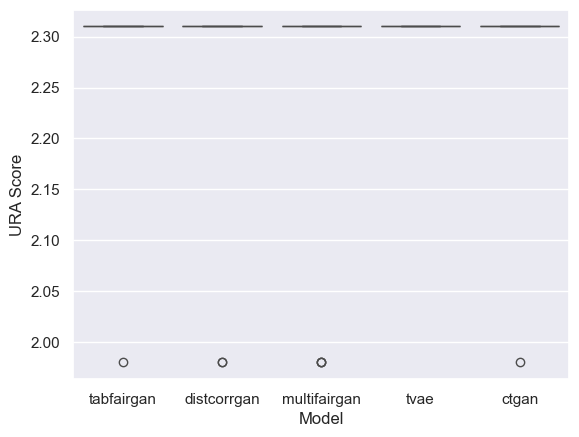

In [13]:
sns.boxplot(x = 'Model', y = 'URA Score', data = data)

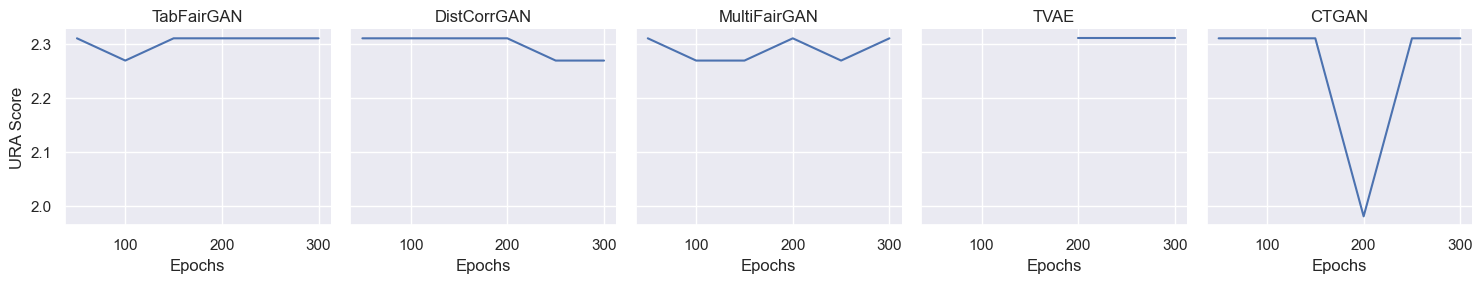

In [14]:
fg = sns.FacetGrid(data = data, col = 'Model')
fg.map(sns.lineplot, 'Epochs', 'URA Score', data = data, errorbar = None)

titles = ['TabFairGAN', 'DistCorrGAN', 'MultiFairGAN', 'TVAE', 'CTGAN']

for ax, title in zip(fg.axes.flat, titles):
    ax.set_title(f"{title}")

### Statistical Tests

<Axes: xlabel='Model', ylabel='Proportion positive numerical tests'>

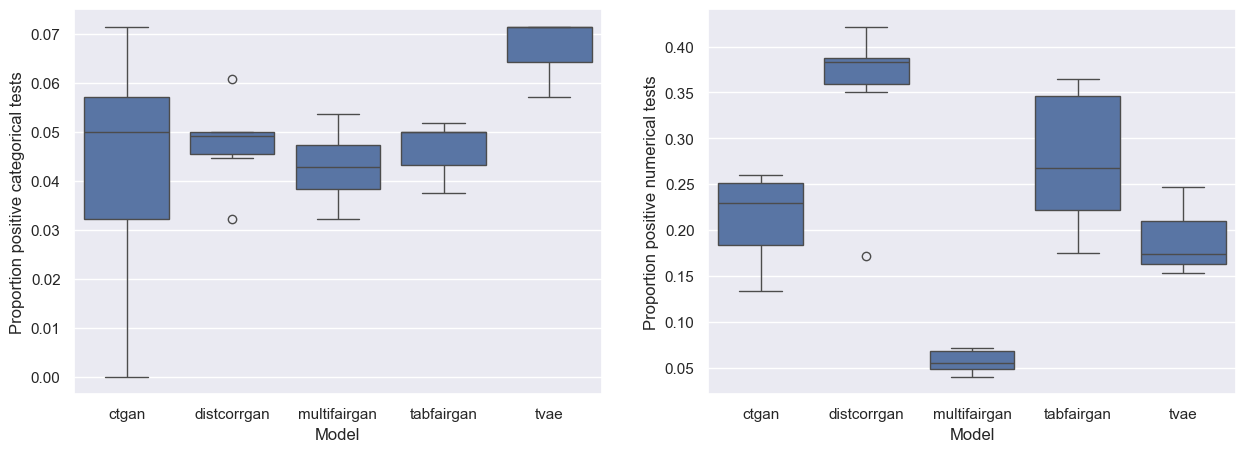

In [15]:
grouped_data_numerical = data.groupby(['Model', 'Epochs'])['Proportion positive numerical tests'].mean()
grouped_data_numerical = grouped_data_numerical.reset_index()
pivot_table_numerical = grouped_data_numerical.pivot(index='Epochs', columns='Model', values='Proportion positive numerical tests')
pivot_table_numerical = pivot_table_numerical.reset_index()
pivot_table_numerical = pivot_table_numerical.melt(id_vars='Epochs', var_name='Model', value_name='Proportion positive numerical tests')

grouped_data_categorical = data.groupby(['Model', 'Epochs'])['Proportion positive categorical tests'].mean()
grouped_data_categorical = grouped_data_categorical.reset_index()
pivot_table_categorical = grouped_data_categorical.pivot(index='Epochs', columns='Model', values='Proportion positive categorical tests')
pivot_table_categorical = pivot_table_categorical.reset_index()
pivot_table_categorical = pivot_table_categorical.melt(id_vars='Epochs', var_name='Model', value_name='Proportion positive categorical tests')

# Falsch!
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Model', y='Proportion positive categorical tests', data = pivot_table_categorical, ax = axes[0])
sns.boxplot(x='Model', y='Proportion positive numerical tests', data=pivot_table_numerical, ax = axes[1])

Text(0.5, 1.0, 'Proportion Positive Categorical Tests Over Epochs')

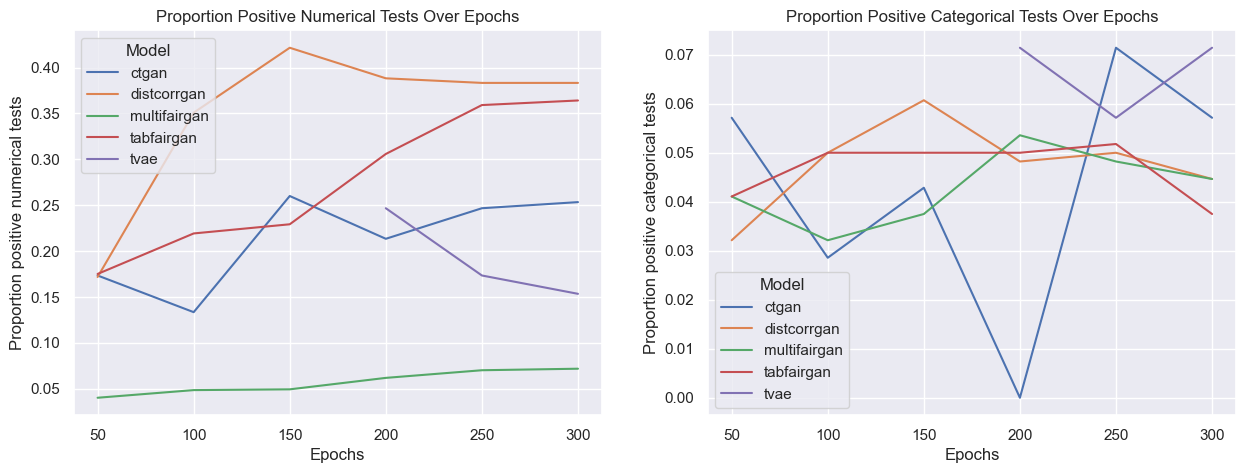

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot on the first axes
sns.lineplot(x='Epochs', y='Proportion positive numerical tests', hue='Model', data=pivot_table_numerical, ax=axes[0])
axes[0].set_title('Proportion Positive Numerical Tests Over Epochs')

# Clear the second axes before plotting 
axes[1].cla()  # Clear the axes

# Plot on the (now cleared) second axes
sns.lineplot(x='Epochs', y='Proportion positive categorical tests', hue='Model', data=pivot_table_categorical, ax=axes[1])
axes[1].set_title('Proportion Positive Categorical Tests Over Epochs')

### Distances

<Axes: xlabel='Model', ylabel='Proportion distances below threshold'>

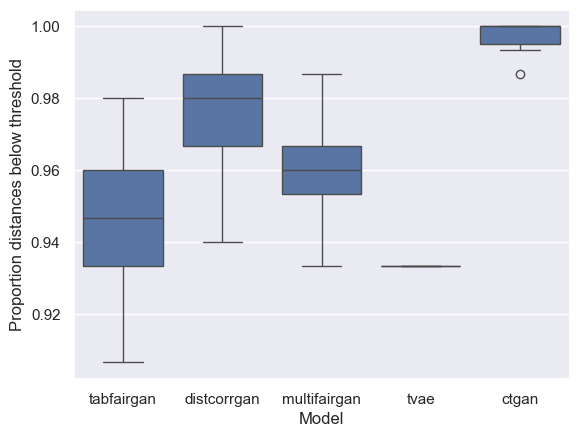

In [18]:
sns.boxplot(x='Model', y='Proportion distances below threshold', data=data)

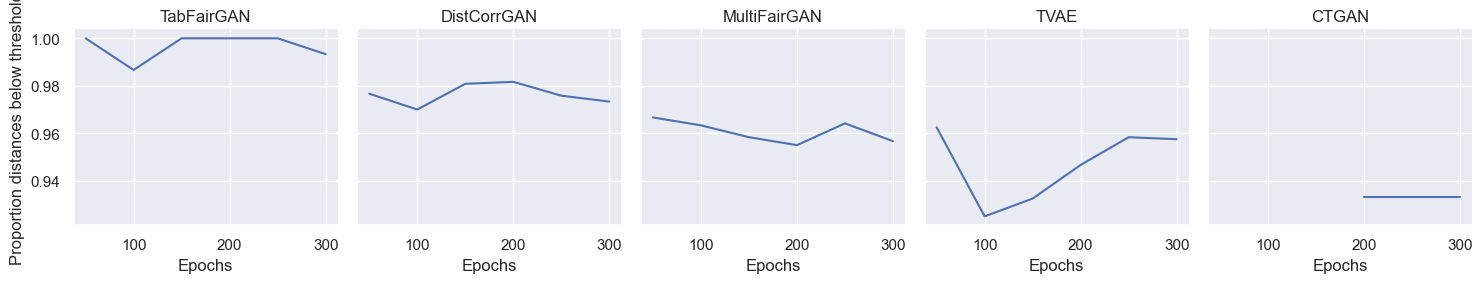

In [21]:
grouped_data_distances = data.groupby(['Model', 'Epochs'])['Proportion distances below threshold'].mean()
grouped_data_distances = grouped_data_distances.reset_index()
pivot_table_distances = grouped_data_distances.pivot(index='Epochs', columns='Model', values='Proportion distances below threshold')
pivot_table_distances = pivot_table_distances.reset_index()
pivot_table_distances = pivot_table_distances.melt(id_vars='Epochs', var_name='Model', value_name='Proportion distances below threshold')

fg = sns.FacetGrid(data=pivot_table_distances, col='Model')
fg.map(sns.lineplot, 'Epochs', 'Proportion distances below threshold', data=pivot_table_distances)

titles = ['TabFairGAN', 'DistCorrGAN', 'MultiFairGAN', 'TVAE', 'CTGAN']

for ax, title in zip(fg.axes.flat, titles):
    ax.set_title(f"{title}")

## MRA Analysis 

### Overall MRA Score

<Axes: xlabel='Model', ylabel='MRA Score'>

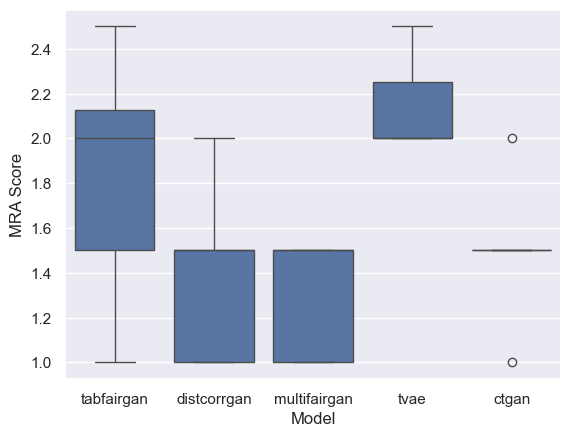

In [23]:
sns.boxplot(x='Model', y='MRA Score', data=data)

### Correlations analysis

#### Numerical correlations

<Axes: xlabel='Model', ylabel='Proportion positive numerical correlations'>

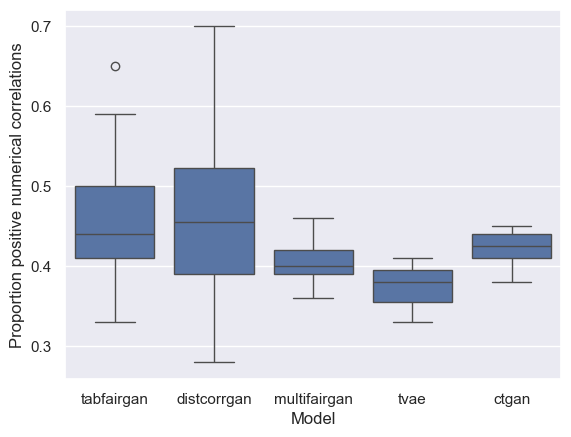

In [24]:
sns.boxplot(x='Model', y='Proportion positive numerical correlations', data=data)

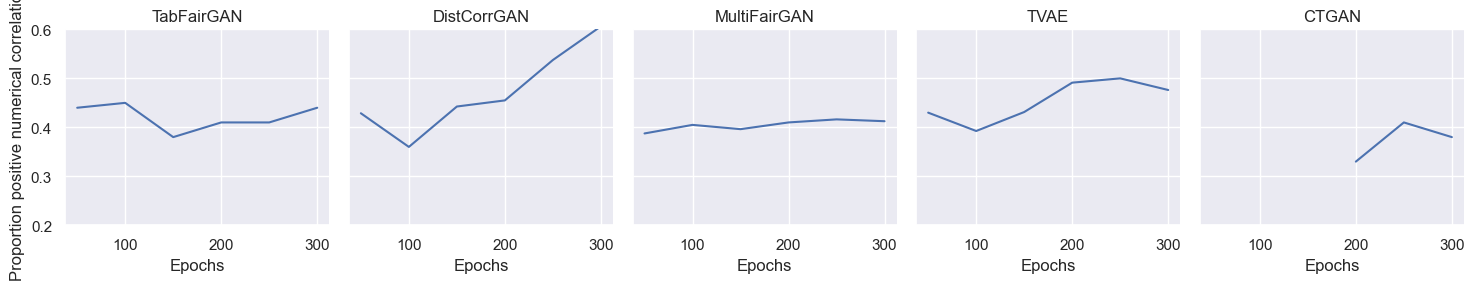

In [30]:
grouped_data_correlation_numerical = data.groupby(['Model', 'Epochs'])['Proportion positive numerical correlations'].mean()
grouped_data_correlation_numerical = grouped_data_correlation_numerical.reset_index()
pivot_table_correlation_numerical = grouped_data_correlation_numerical.pivot(index='Epochs', columns='Model', values='Proportion positive numerical correlations')
pivot_table_correlation_numerical = pivot_table_correlation_numerical.reset_index()
pivot_table_correlation_numerical = pivot_table_correlation_numerical.melt(id_vars='Epochs', var_name='Model', value_name='Proportion positive numerical correlations')

fg = sns.FacetGrid(data=pivot_table_correlation_numerical, col='Model')
fg.map(sns.lineplot, 'Epochs', 'Proportion positive numerical correlations', data=pivot_table_correlation_numerical)
plt.ylim(0.2, 0.6)

titles = ['TabFairGAN', 'DistCorrGAN', 'MultiFairGAN', 'TVAE', 'CTGAN']

for ax, title in zip(fg.axes.flat, titles):
    ax.set_title(f"{title}")

#### Categorical correlations

<Axes: xlabel='Model', ylabel='Proportion positive categorical correlations'>

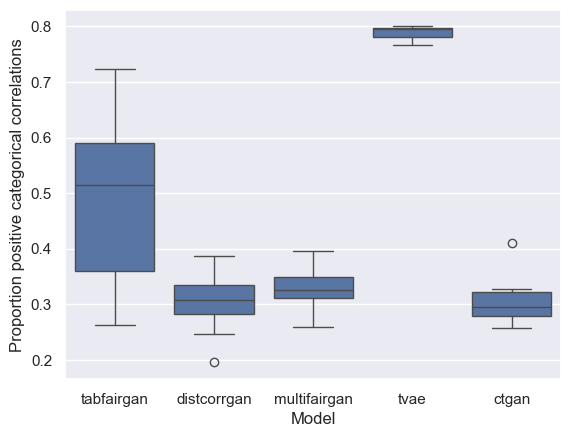

In [29]:
sns.boxplot(x='Model', y='Proportion positive categorical correlations', data=data)

ValueError: No axis named Epochs for object type DataFrame